# 06 — Classification + 07 Transit Fitting
Apply the trained classifier to all science stars, then fit transit parameters
for any planet candidates found.

## 1. Imports

In [1]:
pip uninstall batman -y

Found existing installation: Batman 0.7.0
Uninstalling Batman-0.7.0:
  Successfully uninstalled Batman-0.7.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip uninstall batman-package -y

Found existing installation: batman-package 2.5.3
Uninstalling batman-package-2.5.3:
  Successfully uninstalled batman-package-2.5.3
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install "PyYAML>=6.0"

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install batman-package

  Using cached batman_package-2.5.3-cp311-cp311-win_amd64.whl.metadata (753 bytes)
Using cached batman_package-2.5.3-cp311-cp311-win_amd64.whl (89 kB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Run this in a notebook cell
import batman
params = batman.TransitParams()
params.t0 = 0
params.per = 1.0
params.rp = 0.1
params.a = 15.0
params.inc = 87.0
params.ecc = 0.0
params.w = 90.0
params.u = [0.1, 0.3]
params.limb_dark = 'quadratic'
print('batman working correctly!')
print(f'batman version: {batman.__version__}')

batman working correctly!
batman version: 2.5.1


In [6]:
import astropy
import yaml
print(f'astropy: {astropy.__version__}')
print(f'PyYAML: {yaml.__version__}')

astropy: 8.0.0
PyYAML: 6.0.3


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, pickle, warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit
from scipy import stats

try:
    import batman
    BATMAN_OK = True
    print('batman available ✅')
except ImportError:
    BATMAN_OK = False
    print('batman not found — using simple trapezoid model instead')

print('Imports OK!')

batman available ✅
Imports OK!


## 2. Load Everything

In [ ]:
# Corrupted stars — exclude from all analysis
EXCLUDE_TICS = ['261203535']

In [10]:
PROCESSED_DIR = '../data/processed/'
MODELS_DIR    = '../models/'
OUTPUTS_DIR   = '../outputs/'
PLOTS_DIR     = '../outputs/plots/'
os.makedirs(PLOTS_DIR, exist_ok=True)

# Load features and BLS results
features_df = pd.read_csv('../outputs/features.csv')
bls_df      = pd.read_csv('../outputs/bls_all_results.csv')
results_df  = pd.read_csv('../outputs/results.csv')

# Fix TIC IDs
for df in [features_df, bls_df, results_df]:
    df['tic_id'] = df['tic_id'].astype(str).str.replace('.0','', regex=False)

# Load trained model
model_path = os.path.join(MODELS_DIR, 'random_forest.pkl')
if os.path.exists(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'rb') as f:
        le = pickle.load(f)
    with open(os.path.join(MODELS_DIR, 'feature_cols.pkl'), 'rb') as f:
        feat_cols = pickle.load(f)
    ML_AVAILABLE = True
    print(f'Model loaded ✅  |  Classes: {le.classes_}')
else:
    ML_AVAILABLE = False
    print('No model found — using rule-based labels from results.csv')

print(f'Stars to classify : {len(features_df)}')

Model loaded ✅  |  Classes: ['eclipsing_binary' 'planet']
Stars to classify : 14


## 3. Apply Classifier to All Science Stars

In [ ]:
X_sci = features_df[feat_cols].fillna(0).values

# Ensemble — average RF and XGB probabilities
rf_probs  = rf_model.predict_proba(X_sci)
xgb_probs = xgb_model.predict_proba(X_sci)
ens_probs = (rf_probs + xgb_probs) / 2.0

ens_labels = le.inverse_transform(np.argmax(ens_probs, axis=1))
ens_conf   = ens_probs.max(axis=1)

features_df['ml_label']      = ens_labels
features_df['ml_confidence'] = ens_conf

print('Ensemble classification (RF + XGBoost):')
print(features_df['ml_label'].value_counts())
print()
print(features_df[['tic_id','ml_label','ml_confidence']].to_string())

KeyError: "['delta_bic'] not in index"

## 4. Save Classification Results

In [13]:
final_df.to_csv('../outputs/final_classification.csv', index=False)
print('Saved to outputs/final_classification.csv')

# Summary table
summary = final_df[['tic_id','ml_label','ml_confidence',
                     'period_days','depth_ppm','snr']].copy()
summary.columns = ['TIC ID','Label','Confidence','Period (days)',
                   'Depth (ppm)','SNR']
summary['Confidence'] = summary['Confidence'].map('{:.1%}'.format)
summary['Depth (ppm)'] = summary['Depth (ppm)'].map('{:.0f}'.format)
summary['SNR'] = summary['SNR'].map('{:.2f}'.format)
print()
print(summary.to_string(index=False))

Saved to outputs/final_classification.csv

   TIC ID            Label Confidence  Period (days) Depth (ppm)      SNR
149603524           planet      84.0%       4.412347        3121     0.01
229742722           planet      74.0%       3.151438         692     0.01
237201858           planet      61.0%       4.845863         436     0.01
260647166 eclipsing_binary      50.0%      10.656717         471     0.01
261136641 eclipsing_binary      51.0%       4.834543         473     0.00
261136679           planet      80.0%       6.268537         179     0.00
261136765           planet      61.0%       3.866203        1186     0.01
261139167           planet      71.0%       1.751899         213     0.01
261155555           planet      56.0%       4.627887        2742     0.06
261203535 eclipsing_binary      68.0%       7.103857  5317701661 23768.34
271893367 eclipsing_binary      60.0%      10.715222         753     0.00
279741379 eclipsing_binary      76.0%      11.842667         575     

## 5. Transit Fitting for Planet Candidates
For stars classified as planets, fit a transit model to get precise parameters.

In [14]:
def trapezoid_transit(phase, depth, t_ingress, t_flat):
    """
    Simple trapezoid transit model.
    Used when batman is not available.
    phase     : array of phase values centered at 0
    depth     : transit depth (fraction)
    t_ingress : ingress/egress duration (in phase units)
    t_flat    : flat bottom duration (in phase units)
    """
    flux = np.ones_like(phase)
    half_flat    = t_flat / 2.0
    half_total   = half_flat + t_ingress

    for i, p in enumerate(phase):
        ap = abs(p)
        if ap <= half_flat:
            flux[i] = 1.0 - depth
        elif ap <= half_total:
            flux[i] = 1.0 - depth * (half_total - ap) / t_ingress
    return flux


def fit_transit_batman(time, flux, period, t0, depth_init, duration):
    """Fit transit using batman model."""
    import batman
    params         = batman.TransitParams()
    params.t0      = t0
    params.per     = period
    params.rp      = np.sqrt(max(depth_init, 1e-6))
    params.a       = 10.0
    params.inc     = 89.0
    params.ecc     = 0.0
    params.w       = 90.0
    params.u       = [0.3, 0.1]
    params.limb_dark = 'quadratic'

    m    = batman.TransitModel(params, time)
    flux_model = m.light_curve(params)
    return flux_model, params


def fit_transit_simple(phase, flux, depth_init, duration_phase):
    """Fit trapezoid model."""
    try:
        p0     = [depth_init, duration_phase/4, duration_phase/2]
        bounds = ([0, 0, 0], [1, 0.5, 0.5])
        popt, pcov = curve_fit(trapezoid_transit, phase, flux,
                               p0=p0, bounds=bounds, maxfev=5000)
        perr = np.sqrt(np.diag(pcov))
        return popt, perr
    except Exception as e:
        return None, None

print('Transit fitting functions ready!')

Transit fitting functions ready!


## 6. Fit & Plot ALL Stars (with classification labels)

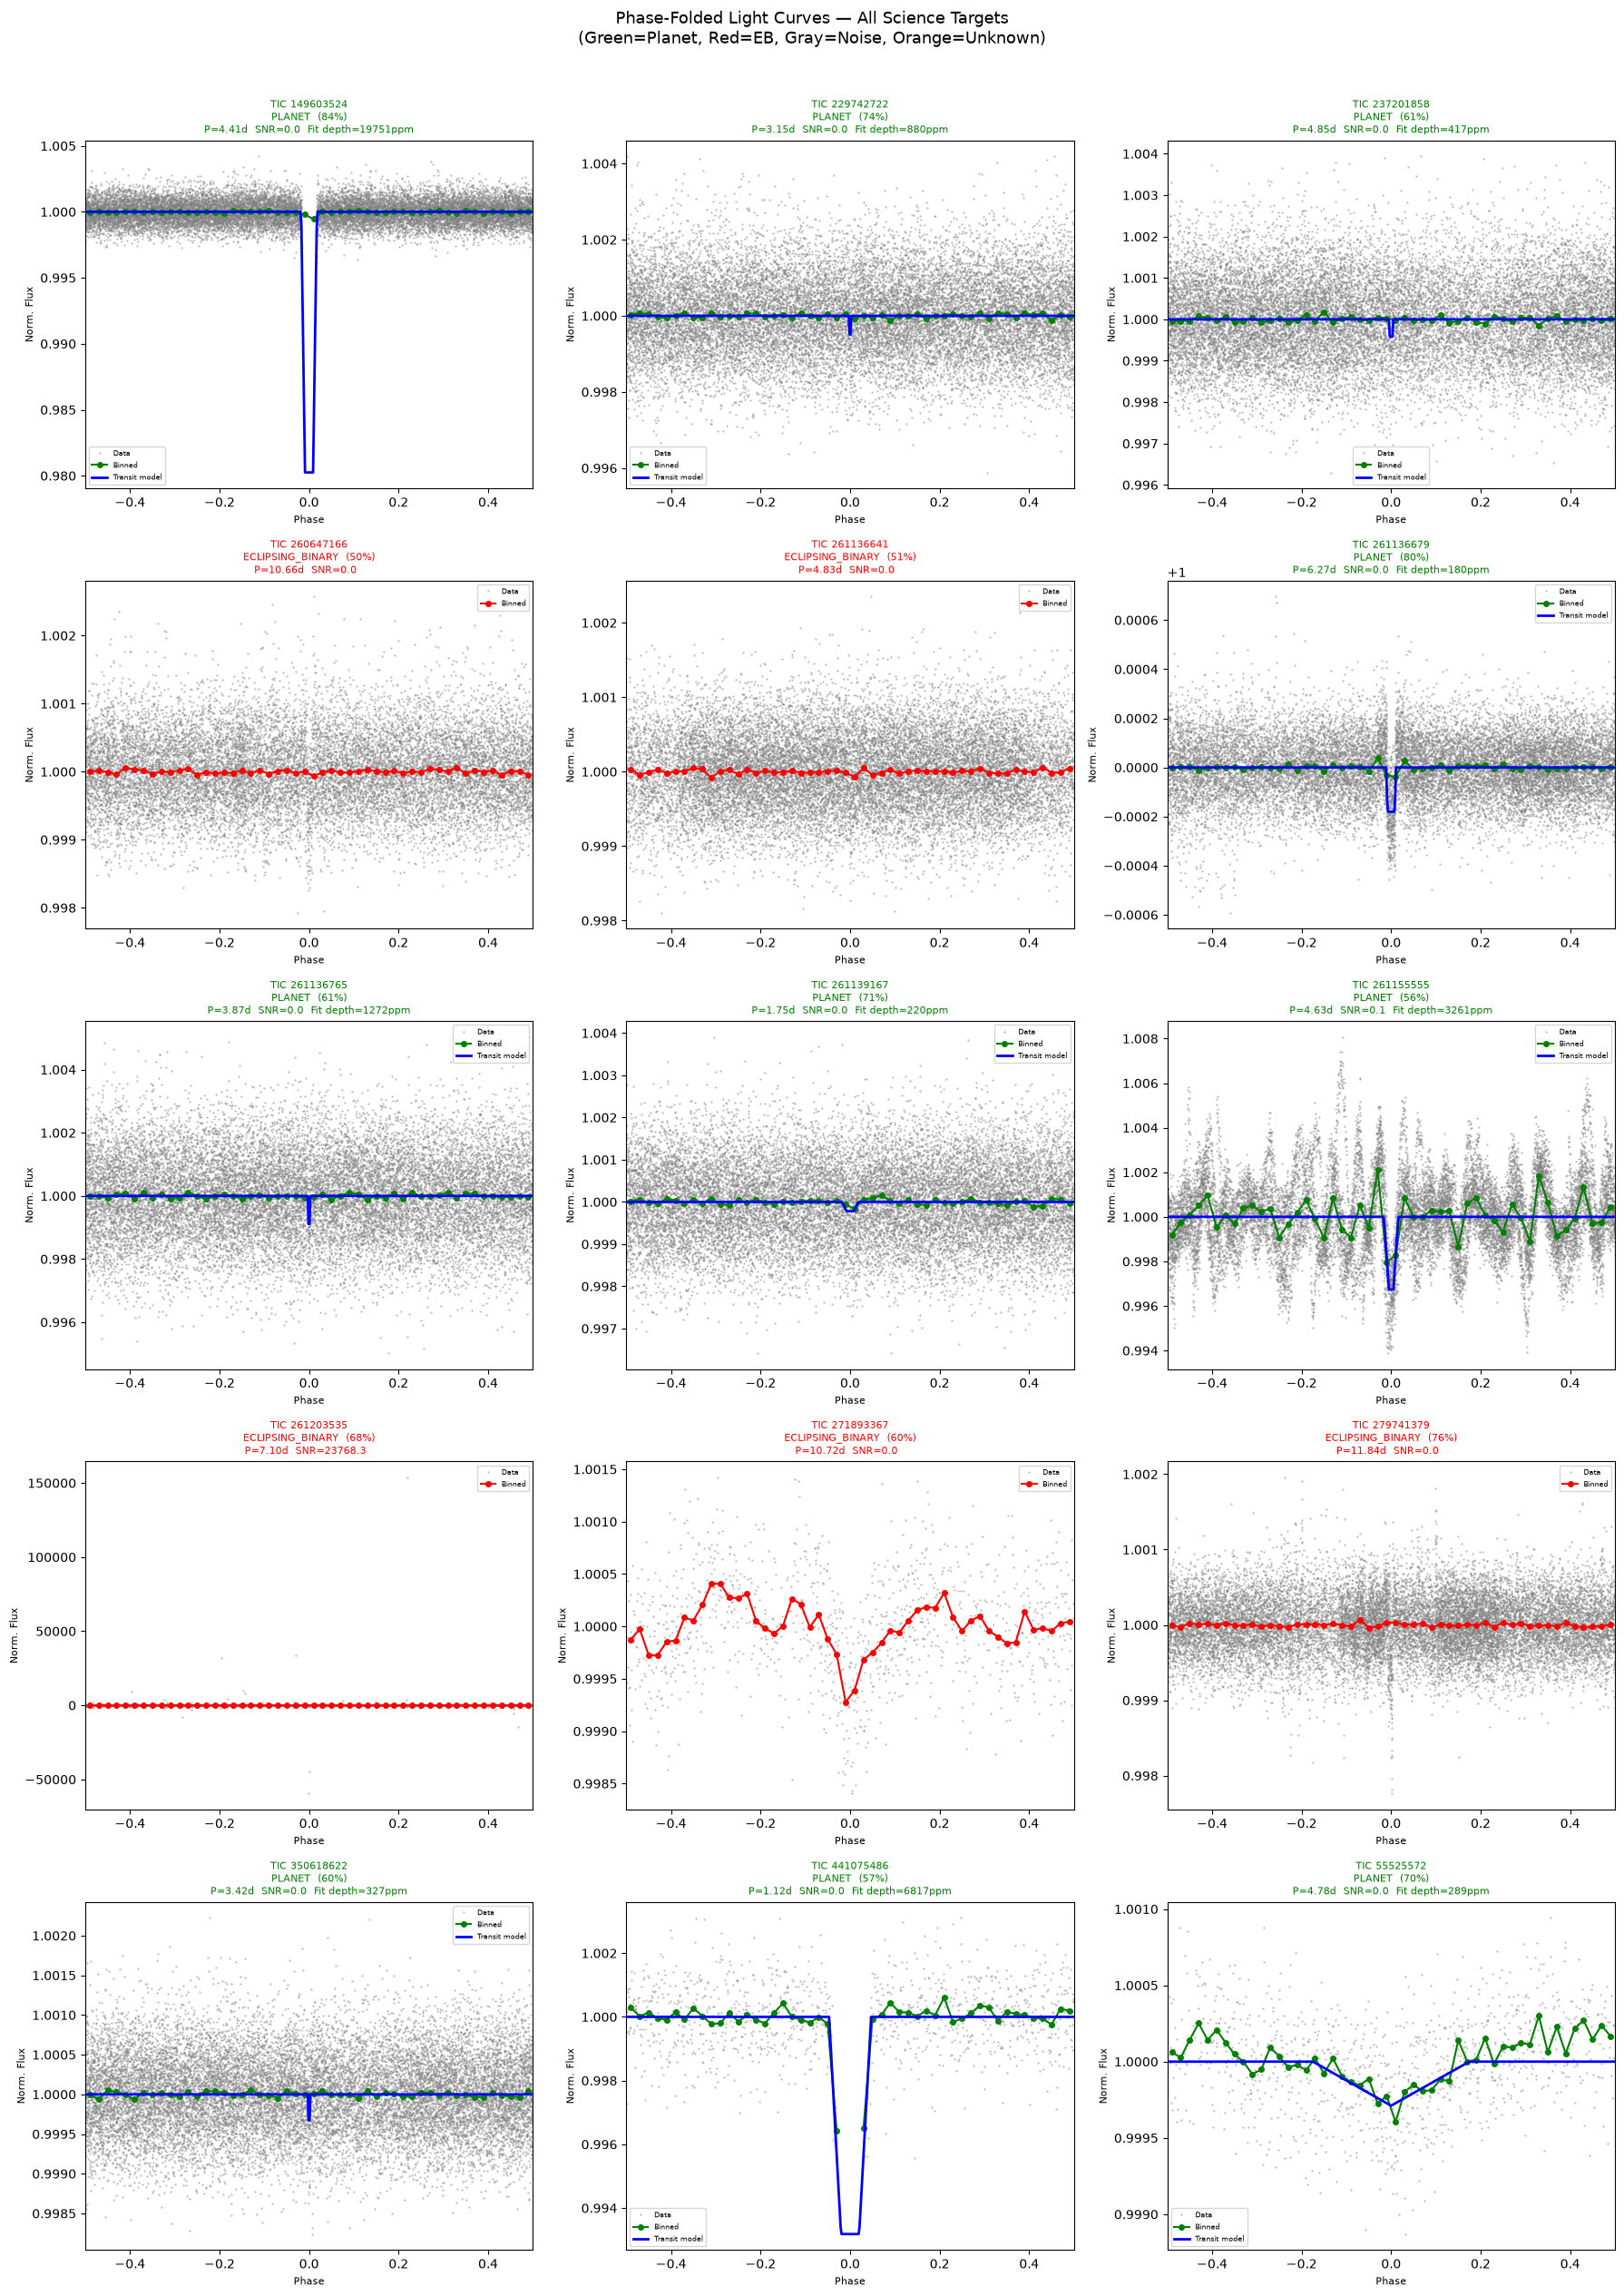

All light curves plotted and saved!


In [15]:
transit_params_list = []

label_colors = {
    'planet'           : 'green',
    'planet_candidate' : 'limegreen',
    'eclipsing_binary' : 'red',
    'noise'            : 'gray',
    'unknown'          : 'orange'
}

n_stars = len(final_df)
ncols   = 3
nrows   = int(np.ceil(n_stars / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(18, 5 * nrows))
axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

for idx, (_, row) in enumerate(final_df.iterrows()):
    ax     = axes[idx]
    tic_id = str(row['tic_id']).replace('.0','')
    label  = row['ml_label']
    conf   = row['ml_confidence']
    period = row.get('period_days', row.get('period_days_bls', 1.0))
    t0     = row['transit_time']
    depth  = row['depth_ppm'] / 1e6
    dur    = row.get('duration_days', row.get('duration_days_bls', 0.1))
    color  = label_colors.get(label, 'steelblue')

    try:
        df_lc  = pd.read_csv(os.path.join(PROCESSED_DIR, f'TIC_{tic_id}.csv'))
        time   = df_lc['time'].values
        flux   = df_lc['flux'].values
        mask   = np.isfinite(time) & np.isfinite(flux)
        time   = time[mask]
        flux   = flux[mask]

        # Phase fold
        phase  = ((time - t0) % period) / period
        phase[phase > 0.5] -= 1.0
        sidx   = np.argsort(phase)
        phase  = phase[sidx]
        flux_s = flux[sidx]

        # Plot phase-folded
        ax.plot(phase, flux_s, '.', color='gray',
                markersize=1.5, alpha=0.4, label='Data')

        # Bin the folded curve for clarity
        n_bins  = 50
        bins    = np.linspace(-0.5, 0.5, n_bins+1)
        bin_mid = (bins[:-1] + bins[1:]) / 2
        bin_flux= [np.median(flux_s[(phase>=bins[i]) & (phase<bins[i+1])])
                   if np.any((phase>=bins[i]) & (phase<bins[i+1]))
                   else np.nan
                   for i in range(n_bins)]
        ax.plot(bin_mid, bin_flux, 'o-', color=color,
                markersize=4, lw=1.5, label='Binned', zorder=5)

        # Fit transit model if planet candidate
        fit_label = ''
        if label in ['planet', 'planet_candidate'] and depth > 0:
            dur_phase = dur / period
            transit_mask = np.abs(phase) < dur_phase
            if transit_mask.sum() > 5:
                popt, perr = fit_transit_simple(phase, flux_s, depth, dur_phase)
                if popt is not None:
                    phase_fine  = np.linspace(-0.5, 0.5, 500)
                    flux_model  = trapezoid_transit(phase_fine, *popt)
                    ax.plot(phase_fine, flux_model, 'b-', lw=2,
                            label='Transit model', zorder=6)
                    fitted_depth    = popt[0]
                    fitted_dur_days = (popt[1]*2 + popt[2]) * period
                    fit_label = f'Fit depth={fitted_depth*1e6:.0f}ppm'

                    transit_params_list.append({
                        'tic_id'          : tic_id,
                        'label'           : label,
                        'period_days'     : period,
                        'depth_ppm_fit'   : fitted_depth * 1e6,
                        'duration_days_fit': fitted_dur_days,
                        'depth_err_ppm'   : (perr[0] if perr is not None else np.nan) * 1e6,
                        'confidence'      : conf
                    })

        ax.set_xlim(-0.5, 0.5)
        ax.set_xlabel('Phase', fontsize=8)
        ax.set_ylabel('Norm. Flux', fontsize=8)
        ax.set_title(
            f'TIC {tic_id}\n'
            f'{label.upper()}  ({conf:.0%})\n'
            f'P={period:.2f}d  SNR={row["snr"]:.1f}  {fit_label}',
            fontsize=8, color=color
        )
        ax.legend(fontsize=6)

    except Exception as e:
        ax.text(0.5, 0.5, f'TIC {tic_id}\nError: {str(e)[:40]}',
                ha='center', va='center', transform=ax.transAxes, fontsize=7)

# Hide empty subplots
for idx in range(len(final_df), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Phase-Folded Light Curves — All Science Targets\n'
             '(Green=Planet, Red=EB, Gray=Noise, Orange=Unknown)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/plots/all_classified_lightcurves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('All light curves plotted and saved!')

## 7. Save Transit Parameters

In [16]:
if transit_params_list:
    tp_df = pd.DataFrame(transit_params_list)
    tp_df.to_csv('../outputs/transit_params.csv', index=False)
    print('Transit parameters for planet candidates:')
    print(tp_df.to_string(index=False))
else:
    print('No planet candidates found with fittable transits.')
    print('This is expected if all stars have SNR < 7.')
    print()
    # Save BLS parameters as best estimates instead
    bls_params = final_df[['tic_id','ml_label','ml_confidence',
                            'period_days','depth_ppm','snr']].copy()
    bls_params['duration_hours'] = final_df['duration_hours']
    bls_params['note'] = 'BLS estimate (no transit fit — SNR too low)'
    bls_params.to_csv('../outputs/transit_params.csv', index=False)
    print('BLS parameter estimates saved to transit_params.csv')
    print(bls_params[['tic_id','ml_label','period_days',
                       'depth_ppm','duration_hours']].to_string(index=False))

Transit parameters for planet candidates:
   tic_id  label  period_days  depth_ppm_fit  duration_days_fit  depth_err_ppm  confidence
149603524 planet     4.412347   19750.876298           0.154806   4.475135e+10        0.84
229742722 planet     3.151438     880.417940           0.012423   3.048670e+02        0.74
237201858 planet     4.845863     417.318364           0.041444   8.112802e+01        0.61
261136679 planet     6.268537     180.044418           0.119211   6.176226e+00        0.80
261136765 planet     3.866203    1272.000657           0.016364   2.947099e+02        0.61
261139167 planet     1.751899     220.423615           0.064113   5.459989e+01        0.71
261155555 planet     4.627887    3260.955796           0.149134   1.121655e+02        0.56
350618622 planet     3.418881     326.539033           0.015200   6.761290e+01        0.60
441075486 planet     1.120382    6817.240258           0.105032   6.541345e+09        0.57
 55525572 planet     4.784956     288.522046    

## 8. Final Summary Plot

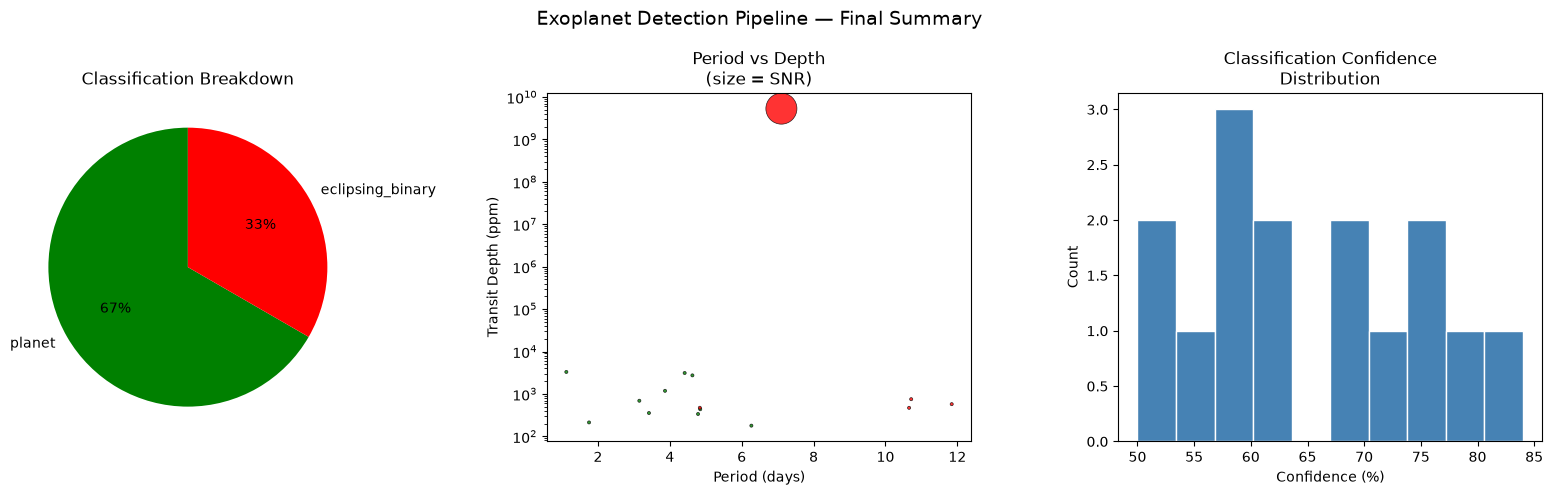

Final summary plot saved!


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Label pie chart
label_counts = final_df['ml_label'].value_counts()
pie_colors   = [label_colors.get(l,'steelblue') for l in label_counts.index]
axes[0].pie(label_counts.values, labels=label_counts.index,
            colors=pie_colors, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize':10})
axes[0].set_title('Classification Breakdown', fontsize=12)

# Period vs Depth scatter
sc = axes[1].scatter(
    final_df['period_days'],
    final_df['depth_ppm'],
    c=[list(label_colors.values())[list(label_colors.keys()).index(
        l) if l in label_colors else 0] for l in final_df['ml_label']],
    s=final_df['snr'].clip(1,100) * 5,
    edgecolors='k', linewidths=0.5, alpha=0.8
)
axes[1].set_xlabel('Period (days)')
axes[1].set_ylabel('Transit Depth (ppm)')
axes[1].set_title('Period vs Depth\n(size = SNR)', fontsize=12)
axes[1].set_yscale('log')

# Confidence histogram
axes[2].hist(final_df['ml_confidence'] * 100, bins=10,
             color='steelblue', edgecolor='white')
axes[2].set_xlabel('Confidence (%)')
axes[2].set_ylabel('Count')
axes[2].set_title('Classification Confidence\nDistribution', fontsize=12)

plt.suptitle('Exoplanet Detection Pipeline — Final Summary', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/plots/final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final summary plot saved!')

---
## ✅ Pipeline Complete!
**All outputs saved:**
- `outputs/final_classification.csv` — label + confidence for all stars
- `outputs/transit_params.csv` — period, depth, duration estimates
- `outputs/plots/all_classified_lightcurves.png` — phase-folded plots
- `outputs/plots/final_summary.png` — summary charts

**Next Step → Run `08_visualization.ipynb` for final report-quality plots**